In [1]:
pip install scipy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 47.2 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


# 1 FDM

### 1.1 FMD code

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM_LogisticAHC:
    """
    1D freezing/thawing soil model
    Logistic unfrozen water content + apparent heat capacity (AHC) method
    """

    def __init__(self, params):
        # ---------------------------
        # Physical parameters
        # ---------------------------
        self.L = params['L']                      # latent heat [MJ/m^3]
        self.C_i = params['C_i']                  # ice volumetric heat capacity
        self.C_l = params['C_l']                  # liquid water volumetric heat capacity
        self.C_f = params['C_f']                  # soil skeleton volumetric heat capacity

        self.lambda_i = params['lambda_i']        # ice thermal conductivity [MJ/(day·m·K)]
        self.lambda_l = params['lambda_l']        # liquid water thermal conductivity
        self.lambda_f = params['lambda_f']        # soil skeleton thermal conductivity

        self.eta = params['eta']                  # porosity / max unfrozen water content upper bound
        self.theta_r = params['theta_r']          # residual unfrozen water content
        self.T_f = params['T_f']                  # freezing transition center temperature
        self.k = params['k']                      # logistic steepness

        # ---------------------------
        # Grid parameters
        # ---------------------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # =========================================================
    # Boundary / initial conditions
    # =========================================================
    def boundary_temperature(self, t):
        """
        Surface temperature boundary condition [degC]
        You can modify this function directly if needed.
        """
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        """
        Initial temperature profile [degC]
        Linear profile from surface initial temperature to bottom temperature.
        """
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        """
        Logistic unfrozen water content:
            theta(T) = theta_r + (eta - theta_r)/(1 + exp(-k*(T - T_f)))
        """
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + np.exp(z))

    def dtheta_dT(self, T):
        """
        Derivative of logistic unfrozen water content:
            dtheta/dT = (eta - theta_r) * k * exp(-k*(T-T_f)) / (1+exp(-k*(T-T_f)))^2
        """
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        ez = np.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        """
        Sensible heat capacity only:
            C_eff = (1-eta) C_f + theta C_l + (eta-theta) C_i
        """
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        """
        Apparent heat capacity:
            C_app = C_eff + L * dtheta/dT
        """
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        """
        Effective conductivity:
            lambda_eff = (1-eta) lambda_f + theta lambda_l + (eta-theta) lambda_i
        """
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # =========================================================
    # Initialization
    # =========================================================
    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = self.initial_temperature_profile(self.x)

    # =========================================================
    # Diagnostics
    # =========================================================
    def print_diagnostics(self, T):
        theta = self.theta_unfrozen(T)
        dth = self.dtheta_dT(T)
        Ceff = self.effective_heat_capacity(T)
        Capp = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range       : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  theta range   : [{np.min(theta):.6f}, {np.max(theta):.6f}]")
        print(f"  dtheta/dT     : [{np.min(dth):.6f}, {np.max(dth):.6f}]")
        print(f"  C_eff range   : [{np.min(Ceff):.6f}, {np.max(Ceff):.6f}]")
        print(f"  C_app range   : [{np.min(Capp):.6f}, {np.max(Capp):.6f}]")
        print(f"  lambda range  : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f}, dt = {self.dt:.6f}")

    # =========================================================
    # Implicit solver
    # =========================================================
    def solve_implicit(self, verbose=True):
        """
        Solve:
            C_app(T) * dT/dt = d/dx( lambda(T) dT/dx )

        Backward-Euler-like implicit discretization with coefficients evaluated at old time step.
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T_old = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit FDM solver (Logistic + Apparent Heat Capacity)...")
            self.print_diagnostics(T_old)

        for n in range(1, self.Nt):
            t_new = self.t[n]

            C_app = self.apparent_heat_capacity(T_old)
            lam = self.effective_conductivity(T_old)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # ---------------------------
            # Top boundary: Dirichlet
            # ---------------------------
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_new)

            # ---------------------------
            # Bottom boundary: Dirichlet
            # ---------------------------
            A[-1, -1] = 1.0
            b[-1] = 1.0

            # ---------------------------
            # Interior nodes
            # ---------------------------
            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lam[i], lam[i + 1])
                lam_m = self.harmonic_mean(lam[i], lam[i - 1])

                coef = self.dt / (C_app[i] * self.dx ** 2)

                A[i, i - 1] = -coef * lam_m
                A[i, i] = 1.0 + coef * (lam_p + lam_m)
                A[i, i + 1] = -coef * lam_p

                b[i] = T_old[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T_old = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T_old)

        return self.T_field

    # =========================================================
    # Post-processing
    # =========================================================
    def get_last_year_data(self):
        if self.T_field is None:
            raise RuntimeError("No results available.")
        t_start = self.T_total - 365.0
        mask = self.t >= t_start
        return self.t[mask] - t_start, self.T_field[:, mask]

    def save_results(self, filename="fdm_logistic_ahc_3years.npz"):
        np.savez(
            filename,
            x=self.x,
            t=self.t,
            T_field=self.T_field,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'theta_r': self.theta_r,
                'T_f': self.T_f,
                'k': self.k
            }
        )
        print(f"Results saved to {filename}")

    def save_last_year_results(self, filename="fdm_logistic_ahc_last_year.npz"):
        t_last, T_last = self.get_last_year_data()
        np.savez(
            filename,
            x=self.x,
            t=t_last,
            T_field=T_last
        )
        print(f"Last-year results saved to {filename}")

    # =========================================================
    # Plotting
    # =========================================================
    def plot_results(self):
        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(self.t, self.x, self.T_field, levels=60, cmap='bwr')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (All Years)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 100, 365, 730, 900, 1094]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(self.t - tt))
            axes[1].plot(self.T_field[:, idx], self.x, label=f't={self.t[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(self.t, self.T_field[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_last_year_results(self):
        t_last, T_last = self.get_last_year_data()

        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(t_last, self.x, T_last, levels=60, cmap='bwr')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time in last year (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (Last Year)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t_last - tt))
            axes[1].plot(T_last[:, idx], self.x, label=f't={t_last[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles (Last Year)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(t_last, T_last[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time in last year (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (Last Year)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

Starting implicit FDM solver (Logistic + Apparent Heat Capacity)...
Diagnostics:
  T range       : [-11.926392, 1.000000]
  theta range   : [0.171456, 0.259736]
  dtheta/dT     : [0.005444, 0.007500]
  C_eff range   : [2.058813, 2.280219]
  C_app range   : [3.876987, 4.774665]
  lambda range  : [0.140898, 0.154207]
  dx = 0.050000, dt = 0.024335
  Progress: 10.0%   elapsed: 0.9s
  Progress: 20.0%   elapsed: 1.7s
  Progress: 30.0%   elapsed: 2.5s
  Progress: 40.0%   elapsed: 3.3s
  Progress: 50.0%   elapsed: 4.2s
  Progress: 60.0%   elapsed: 5.0s
  Progress: 70.0%   elapsed: 7.6s
  Progress: 80.0%   elapsed: 8.5s
  Progress: 90.0%   elapsed: 9.3s
Solution completed in 10.1s
Diagnostics:
  T range       : [-11.926392, 2.393861]
  theta range   : [0.171456, 0.270083]
  dtheta/dT     : [0.005444, 0.007500]
  C_eff range   : [2.058813, 2.306167]
  C_app range   : [3.876987, 4.774924]
  lambda range  : [0.139338, 0.154207]
  dx = 0.050000, dt = 0.024335
All-years T min = -12.079999989780223


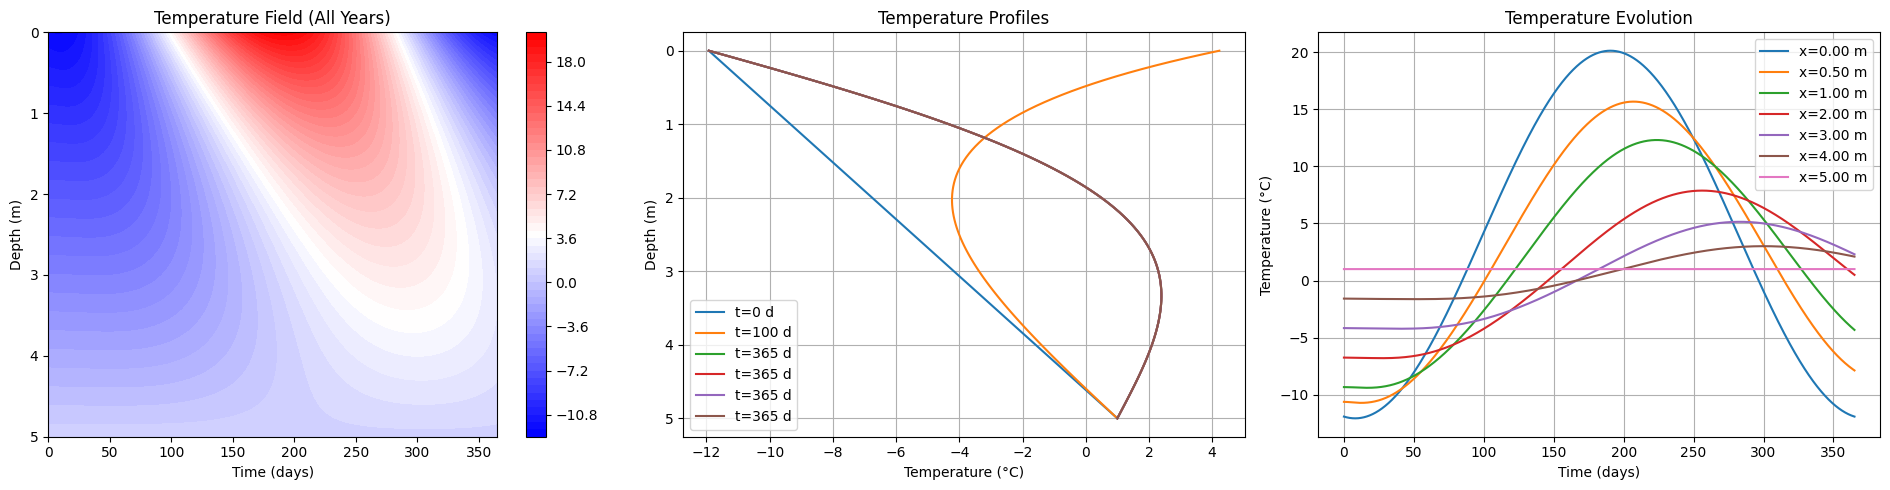

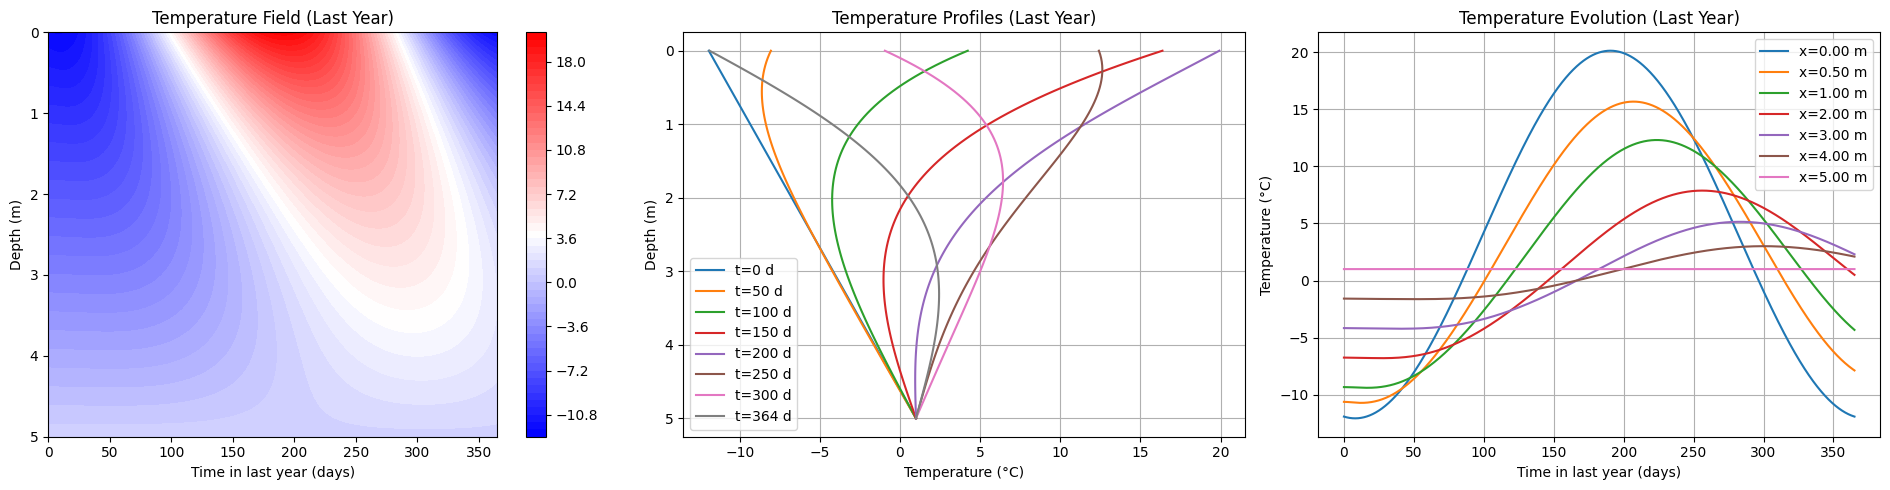

In [3]:
if __name__ == "__main__":
    params = {
        # latent heat and volumetric heat capacities [MJ/m^3/K or MJ/m^3]
        # volumetric latent heat [MJ/m^3]
        'L': 334.0,
        # volumetric heat capacities [MJ/(m^3·K)]
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.60,

        # conductivities converted to MJ/(day·m·K)
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2.000e-6 * 8.64e4,# 2.000e-6 * 8.64e4

        # logistic unfrozen water parameters
        'eta': 0.40,       # porosity [-]
        'theta_r': 0.1,    # residual unfrozen water content
        'T_f': -0.3,        # transition center [degC]
        'k': 0.1           # transition steepness[1/degC]
    }

    model = FreezingSoilFDM_LogisticAHC(params)

    # 3-year simulation
    model.initialize(Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 1)

    T_field_fdm = model.solve_implicit(verbose=True)
    x_fdm = model.x
    t_fdm, T_field_fdm = model.get_last_year_data()
    np.savez(
        "fdm_last_year_result.npz",
        x_fdm=x_fdm,
        t_fdm=t_fdm,
        T_field_fdm=T_field_fdm
    )

    print("All-years T min =", np.min(T_field_fdm))
    print("All-years T max =", np.max(T_field_fdm))
    print("Surface final T =", T_field_fdm[0, -1])
    print("Bottom final T =", T_field_fdm[-1, -1])

    # Plot all years
    model.plot_results()

    # Plot last year
    model.plot_last_year_results()

In [4]:
# 1.400e-6 * 8.64e4,

In [5]:
# (0.121)/8.64e4
# 1.400e-06

# 2. PINNs Inversion Model

In [6]:
import random
import numpy as np
import torch


def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # make results more reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Random initial eta      = 0.36988963
Random initial lambda_f = 0.21953006
Random initial k        = 0.11391964
Random initial C_f      = 1.69471214
Observation points loaded: 135000
True eta value         = 0.4
True lambda_f value    = 0.17279999999999998
True k value           = 0.1
True C_f value         = 1.6
Initial eta guess      = 0.36988961696624756
Initial lambda_f guess = 0.21953006088733673
Initial k guess        = 0.11391963064670563
Initial C_f guess      = 1.6947121620178223
Epoch        1 | Total=3.266063e+03 | PDE=3.427752e-06 | IC=4.188796e+01 | BC=1.547109e+02 | DATA=3.069461e+01 | eta=0.369833 | lambda_f=0.219535 | k=0.113908 | C_f=1.694481 | time=0.9s
Epoch     1000 | Total=3.425854e+00 | PDE=1.741107e-03 | IC=1.178158e-02 | BC=3.991680e-01 | DATA=1.273798e-02 | eta=0.371243 | lambda_f=0.211615 | k=0.112955 | C_f=1.657428 | time=33.9s
Epoch     2000 | Total=5.149091e-01 | PDE=1.747572e-04 | IC=5.019779e-03 | BC=2.071087e-02 | DATA=3.144212e-03 | eta=0.397878 | lambda

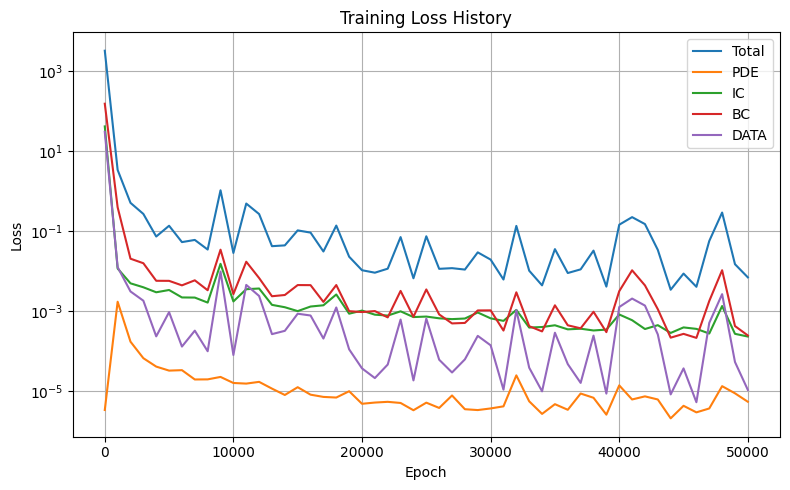

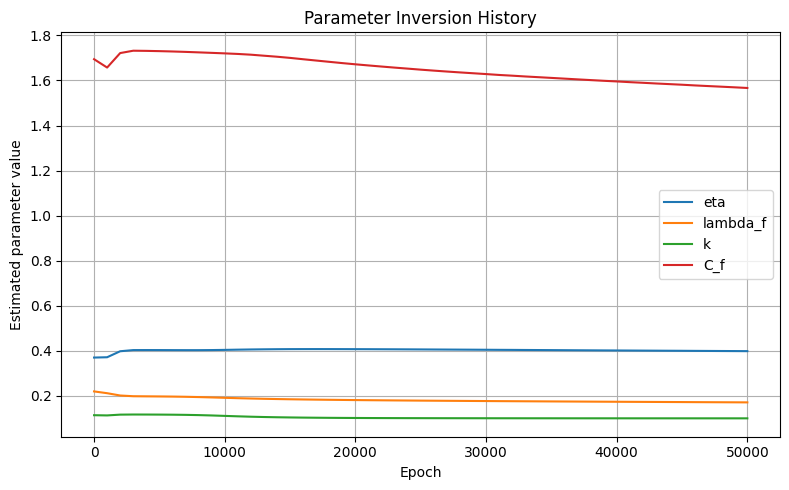

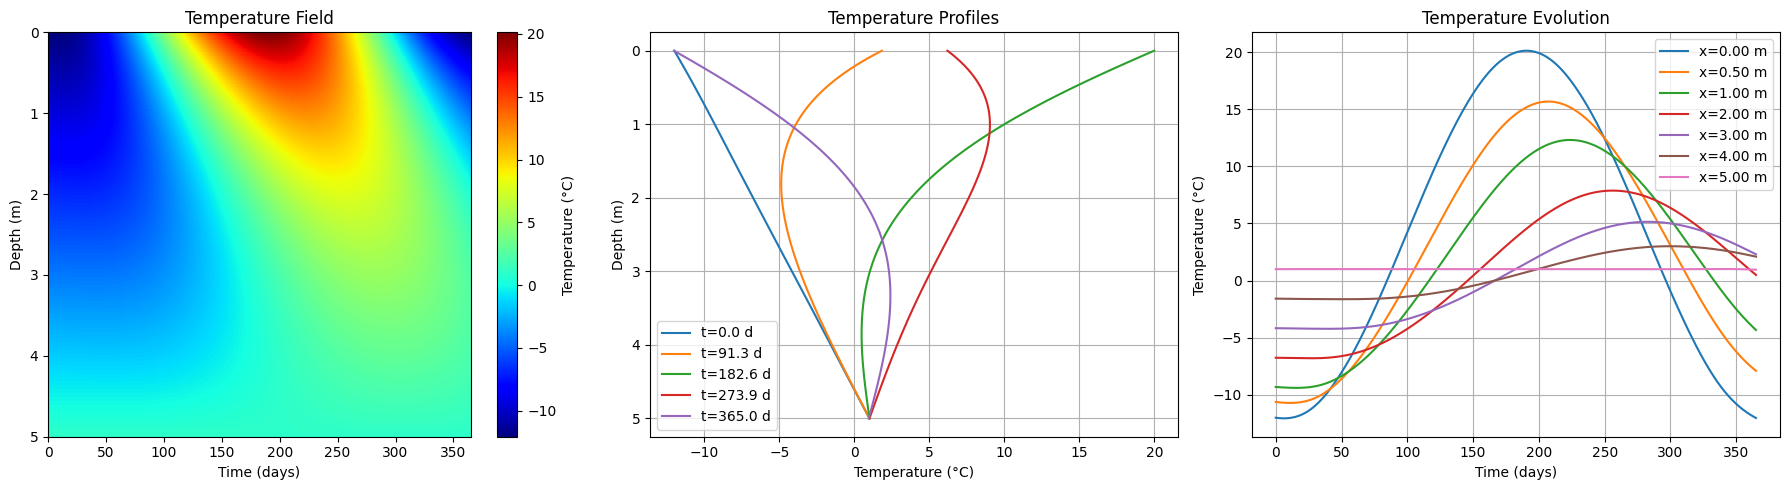

In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time


def set_random_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# =========================================================
# Neural network
# =========================================================
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# =========================================================
# Inverse PINN model for freezing/thawing soil
# =========================================================
class FreezingSoilInversePINN:
    def __init__(self, params, device=None):
        # fixed physical parameters
        self.L = params['L']
        self.C_i = params['C_i']
        self.C_l = params['C_l']

        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']

        self.theta_r = params['theta_r']
        self.T_f = params['T_f']

        self.device = device if device is not None else (
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.model = MLP(in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5).to(self.device)

        self.Lx = None
        self.T_total = None
        self.x_scale = None
        self.t_scale = None

        # true values of inversion parameters
        self.eta_true = params['eta_true']
        self.lambda_f_true = params['lambda_f_true']
        self.k_true = params['k_true']
        self.C_f_true = params['C_f_true']

        # bounded ranges: [0.7, 1.3] * true value
        self.eta_min = 0.7 * self.eta_true
        self.eta_max = 1.3 * self.eta_true

        self.lambda_f_min = 0.7 * self.lambda_f_true
        self.lambda_f_max = 1.3 * self.lambda_f_true

        self.k_min = 0.7 * self.k_true
        self.k_max = 1.3 * self.k_true

        self.C_f_min = 0.7 * self.C_f_true
        self.C_f_max = 1.3 * self.C_f_true

        # random initialization inside bounded ranges
        eta_init = np.random.uniform(self.eta_min, self.eta_max)
        lambda_f_init = np.random.uniform(self.lambda_f_min, self.lambda_f_max)
        k_init = np.random.uniform(self.k_min, self.k_max)
        C_f_init = np.random.uniform(self.C_f_min, self.C_f_max)

        print(f"Random initial eta      = {eta_init:.8f}")
        print(f"Random initial lambda_f = {lambda_f_init:.8f}")
        print(f"Random initial k        = {k_init:.8f}")
        print(f"Random initial C_f      = {C_f_init:.8f}")

        def inverse_bounded_sigmoid(p_init, p_min, p_max):
            z = (p_init - p_min) / (p_max - p_min)
            z = np.clip(z, 1e-6, 1.0 - 1e-6)
            return np.log(z / (1.0 - z))

        eta_raw_init = inverse_bounded_sigmoid(eta_init, self.eta_min, self.eta_max)
        lambda_f_raw_init = inverse_bounded_sigmoid(lambda_f_init, self.lambda_f_min, self.lambda_f_max)
        k_raw_init = inverse_bounded_sigmoid(k_init, self.k_min, self.k_max)
        C_f_raw_init = inverse_bounded_sigmoid(C_f_init, self.C_f_min, self.C_f_max)

        self.eta_raw = nn.Parameter(
            torch.tensor([eta_raw_init], dtype=torch.float32, device=self.device)
        )
        self.lambda_f_raw = nn.Parameter(
            torch.tensor([lambda_f_raw_init], dtype=torch.float32, device=self.device)
        )
        self.k_raw = nn.Parameter(
            torch.tensor([k_raw_init], dtype=torch.float32, device=self.device)
        )
        self.C_f_raw = nn.Parameter(
            torch.tensor([C_f_raw_init], dtype=torch.float32, device=self.device)
        )

        self.loss_history = []
        self.x_data = None
        self.t_data = None
        self.T_data = None

    @property
    def eta(self):
        return self.eta_min + (self.eta_max - self.eta_min) * torch.sigmoid(self.eta_raw)

    @property
    def lambda_f(self):
        return self.lambda_f_min + (self.lambda_f_max - self.lambda_f_min) * torch.sigmoid(self.lambda_f_raw)

    @property
    def k(self):
        return self.k_min + (self.k_max - self.k_min) * torch.sigmoid(self.k_raw)

    @property
    def C_f(self):
        return self.C_f_min + (self.C_f_max - self.C_f_min) * torch.sigmoid(self.C_f_raw)

    # =========================================================
    # Boundary / initial conditions
    # =========================================================
    def boundary_temperature_np(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def boundary_temperature_torch(self, t):
        return 4.03 + 16.11 * torch.sin(2.0 * torch.pi * t / 365.0 - 1.709)

    def initial_temperature_profile_np(self, x):
        T_surface = self.boundary_temperature_np(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    def initial_temperature_profile_torch(self, x):
        T_surface = self.boundary_temperature_torch(torch.zeros_like(x))
        T_bottom = torch.ones_like(x) * 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + torch.exp(z))

    def dtheta_dT(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        ez = torch.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    def dlambda_dT(self, T):
        return (self.lambda_l - self.lambda_i) * self.dtheta_dT(T)

    # =========================================================
    # PINN forward
    # =========================================================
    def net_T(self, x, t):
        x_hat = x / self.x_scale
        t_hat = t / self.t_scale
        inp = torch.cat([x_hat, t_hat], dim=1)
        return self.model(inp)

    # =========================================================
    # PDE residual
    # =========================================================
    def pde_residual(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)

        T = self.net_T(x, t)

        T_t = torch.autograd.grad(
            T, t,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_x = torch.autograd.grad(
            T, x,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_xx = torch.autograd.grad(
            T_x, x,
            grad_outputs=torch.ones_like(T_x),
            create_graph=True,
            retain_graph=True
        )[0]

        C_app = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)
        lam_T = self.dlambda_dT(T)

        residual = C_app * T_t - lam * T_xx - lam_T * (T_x ** 2)
        return residual

    # =========================================================
    # Sampling
    # =========================================================
    def sample_collocation(self, N_f):
        x = np.random.rand(N_f, 1) * self.Lx
        t = np.random.rand(N_f, 1) * self.T_total
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device)
        )

    def sample_initial(self, N_i):
        x = np.random.rand(N_i, 1) * self.Lx
        t = np.zeros((N_i, 1))
        T0 = self.initial_temperature_profile_np(x)
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T0, dtype=torch.float32, device=self.device)
        )

    def sample_boundary(self, N_b):
        t = np.random.rand(N_b, 1) * self.T_total

        x_top = np.zeros((N_b, 1))
        T_top = self.boundary_temperature_np(t)

        x_bot = np.ones((N_b, 1)) * self.Lx
        T_bot = np.ones((N_b, 1)) * 1.0

        return (
            torch.tensor(x_top, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T_top, dtype=torch.float32, device=self.device),
            torch.tensor(x_bot, dtype=torch.float32, device=self.device),
            torch.tensor(T_bot, dtype=torch.float32, device=self.device),
        )

    # =========================================================
    # Observation data
    # =========================================================
    def add_temperature_observations(self, x_obs, t_obs, T_obs):
        self.x_data = torch.tensor(x_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)
        self.t_data = torch.tensor(t_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)
        self.T_data = torch.tensor(T_obs, dtype=torch.float32, device=self.device).reshape(-1, 1)

    # =========================================================
    # Loss function
    # =========================================================
    def loss_function(self, N_f, N_i, N_b, w_pde=1.0, w_ic=1.0, w_bc=1.0, w_data=1.0):
        x_f, t_f = self.sample_collocation(N_f)
        res_f = self.pde_residual(x_f, t_f)
        loss_pde = torch.mean(res_f ** 2)

        x_i, t_i, T_i = self.sample_initial(N_i)
        T_i_pred = self.net_T(x_i, t_i)
        loss_ic = torch.mean((T_i_pred - T_i) ** 2)

        x_top, t_b, T_top, x_bot, T_bot = self.sample_boundary(N_b)
        T_top_pred = self.net_T(x_top, t_b)
        T_bot_pred = self.net_T(x_bot, t_b)

        loss_bc_top = torch.mean((T_top_pred - T_top) ** 2)
        loss_bc_bot = torch.mean((T_bot_pred - T_bot) ** 2)
        loss_bc = loss_bc_top + loss_bc_bot

        if self.x_data is not None:
            T_data_pred = self.net_T(self.x_data, self.t_data)
            loss_data = torch.mean((T_data_pred - self.T_data) ** 2)
        else:
            loss_data = torch.tensor(0.0, device=self.device)

        total_loss = (
            w_pde * loss_pde +
            w_ic * loss_ic +
            w_bc * loss_bc +
            w_data * loss_data
        )

        return total_loss, loss_pde, loss_ic, loss_bc, loss_data

    # =========================================================
    # Training
    # =========================================================
    def train(
        self,
        Lx,
        T_total,
        epochs_adam=100000,
        lr=1e-3,
        N_f=8000,
        N_i=1000,
        N_b=1000,
        w_pde=100.0,
        w_ic=1.0,
        w_bc=1.0,
        w_data=100.0,
        print_every=1000,
        use_lbfgs=True
    ):
        self.Lx = Lx
        self.T_total = T_total
        self.x_scale = Lx
        self.t_scale = T_total

        params_to_optimize = (
            list(self.model.parameters()) +
            [self.eta_raw, self.lambda_f_raw, self.k_raw, self.C_f_raw]
        )

        optimizer = torch.optim.Adam(params_to_optimize, lr=lr)
        start_time = time.time()

        for epoch in range(1, epochs_adam + 1):
            optimizer.zero_grad()

            total_loss, loss_pde, loss_ic, loss_bc, loss_data = self.loss_function(
                N_f=N_f, N_i=N_i, N_b=N_b,
                w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
            )

            total_loss.backward()
            optimizer.step()

            if epoch % print_every == 0 or epoch == 1:
                eta_val = self.eta.item()
                lambda_f_val = self.lambda_f.item()
                k_val = self.k.item()
                C_f_val = self.C_f.item()

                self.loss_history.append([
                    epoch,
                    total_loss.item(),
                    loss_pde.item(),
                    loss_ic.item(),
                    loss_bc.item(),
                    loss_data.item(),
                    eta_val,
                    lambda_f_val,
                    k_val,
                    C_f_val
                ])

                elapsed = time.time() - start_time
                print(
                    f"Epoch {epoch:8d} | "
                    f"Total={total_loss.item():.6e} | "
                    f"PDE={loss_pde.item():.6e} | "
                    f"IC={loss_ic.item():.6e} | "
                    f"BC={loss_bc.item():.6e} | "
                    f"DATA={loss_data.item():.6e} | "
                    f"eta={eta_val:.6f} | "
                    f"lambda_f={lambda_f_val:.6f} | "
                    f"k={k_val:.6f} | "
                    f"C_f={C_f_val:.6f} | "
                    f"time={elapsed:.1f}s"
                )

        if use_lbfgs:
            print("\nStarting L-BFGS optimization ...")

            optimizer_lbfgs = torch.optim.LBFGS(
                params_to_optimize,
                lr=1.0,
                max_iter=2000,
                max_eval=2500,
                history_size=50,
                tolerance_grad=1e-9,
                tolerance_change=1e-11,
                line_search_fn="strong_wolfe"
            )

            iteration_counter = [0]

            def closure():
                optimizer_lbfgs.zero_grad()

                total_loss, loss_pde, loss_ic, loss_bc, loss_data = self.loss_function(
                    N_f=N_f, N_i=N_i, N_b=N_b,
                    w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
                )

                total_loss.backward()

                iteration_counter[0] += 1
                if iteration_counter[0] % 50 == 0:
                    eta_val = self.eta.item()
                    lambda_f_val = self.lambda_f.item()
                    k_val = self.k.item()
                    C_f_val = self.C_f.item()

                    self.loss_history.append([
                        epochs_adam + iteration_counter[0],
                        total_loss.item(),
                        loss_pde.item(),
                        loss_ic.item(),
                        loss_bc.item(),
                        loss_data.item(),
                        eta_val,
                        lambda_f_val,
                        k_val,
                        C_f_val
                    ])

                    print(
                        f"[LBFGS {iteration_counter[0]:5d}] "
                        f"Total={total_loss.item():.6e} | "
                        f"PDE={loss_pde.item():.6e} | "
                        f"IC={loss_ic.item():.6e} | "
                        f"BC={loss_bc.item():.6e} | "
                        f"DATA={loss_data.item():.6e} | "
                        f"eta={eta_val:.6f} | "
                        f"lambda_f={lambda_f_val:.6f} | "
                        f"k={k_val:.6f} | "
                        f"C_f={C_f_val:.6f}"
                    )

                return total_loss

            optimizer_lbfgs.step(closure)

        print("\nTraining finished.")
        print(f"Estimated eta      = {self.eta.item():.8f}")
        print(f"Estimated lambda_f = {self.lambda_f.item():.8f}")
        print(f"Estimated k        = {self.k.item():.8f}")
        print(f"Estimated C_f      = {self.C_f.item():.8f}")

    # =========================================================
    # Prediction
    # =========================================================
    def predict_field(self, Nx=101, Nt=15000):
        x = np.linspace(0.0, self.Lx, Nx)
        t = np.linspace(0.0, self.T_total, Nt)

        XX, TT = np.meshgrid(x, t, indexing='ij')

        x_in = torch.tensor(XX.reshape(-1, 1), dtype=torch.float32, device=self.device)
        t_in = torch.tensor(TT.reshape(-1, 1), dtype=torch.float32, device=self.device)

        self.model.eval()
        with torch.no_grad():
            T_pred = self.net_T(x_in, t_in).cpu().numpy().reshape(Nx, Nt)

        return x, t, T_pred

    # =========================================================
    # Plot
    # =========================================================
    def plot_loss(self):
        hist = np.array(self.loss_history)
        if hist.size == 0:
            print("No training history found.")
            return

        plt.figure(figsize=(8, 5))
        plt.semilogy(hist[:, 0], hist[:, 1], label='Total')
        plt.semilogy(hist[:, 0], hist[:, 2], label='PDE')
        plt.semilogy(hist[:, 0], hist[:, 3], label='IC')
        plt.semilogy(hist[:, 0], hist[:, 4], label='BC')
        plt.semilogy(hist[:, 0], hist[:, 5], label='DATA')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss History")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(hist[:, 0], hist[:, 6], label='eta')
        plt.plot(hist[:, 0], hist[:, 7], label='lambda_f')
        plt.plot(hist[:, 0], hist[:, 8], label='k')
        plt.plot(hist[:, 0], hist[:, 9], label='C_f')
        plt.xlabel("Epoch")
        plt.ylabel("Estimated parameter value")
        plt.title("Parameter Inversion History")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_results(self, Nx=101, Nt=1500):
        x, t, T_field = self.predict_field(Nx=Nx, Nt=Nt)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im = axes[0].imshow(
            T_field,
            extent=[t.min(), t.max(), x.max(), x.min()],
            aspect='auto',
            cmap='jet'
        )
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field')
        plt.colorbar(im, ax=axes[0], label='Temperature (°C)')

        t_indices = [0, Nt // 4, Nt // 2, 3 * Nt // 4, Nt - 1]
        for idx in t_indices:
            axes[1].plot(T_field[:, idx], x, label=f't={t[idx]:.1f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(x - dd))
            axes[2].plot(t, T_field[idx, :], label=f'x={x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


# =========================================================
# Helper: build observation data from FDM file
# =========================================================
def load_inverse_observation_from_fdm(npz_file, internal_depths=None):
    if internal_depths is None:
        internal_depths = np.arange(0.5, 5.0, 0.5)

    data = np.load(npz_file)
    x_fdm = data["x_fdm"]
    t_fdm = data["t_fdm"]
    T_field_fdm = data["T_field_fdm"]

    x_obs_list = []
    t_obs_list = []
    T_obs_list = []

    for depth in internal_depths:
        idx = np.argmin(np.abs(x_fdm - depth))
        x_val = x_fdm[idx]

        for j, tt in enumerate(t_fdm):
            x_obs_list.append(x_val)
            t_obs_list.append(tt)
            T_obs_list.append(T_field_fdm[idx, j])

    x_obs = np.array(x_obs_list).reshape(-1, 1)
    t_obs = np.array(t_obs_list).reshape(-1, 1)
    T_obs = np.array(T_obs_list).reshape(-1, 1)

    return x_obs, t_obs, T_obs


# =========================================================
# Example main
# =========================================================
if __name__ == "__main__":
    set_random_seed(42)

    params = {
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,

        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,

        # true values of inversion parameters
        'eta_true': 0.40,
        'lambda_f_true': 2.000e-6 * 8.64e4,   # 0.1728
        'k_true': 0.10,
        'C_f_true': 1.60,

        'theta_r': 0.10,
        'T_f': -0.3
    }

    pinn = FreezingSoilInversePINN(params)

    x_obs, t_obs, T_obs = load_inverse_observation_from_fdm(
        "fdm_last_year_result.npz",
        internal_depths=np.arange(0.5, 5.0, 0.5)
    )
    pinn.add_temperature_observations(x_obs, t_obs, T_obs)

    print("Observation points loaded:", len(T_obs))
    print("True eta value         =", params['eta_true'])
    print("True lambda_f value    =", params['lambda_f_true'])
    print("True k value           =", params['k_true'])
    print("True C_f value         =", params['C_f_true'])
    print("Initial eta guess      =", pinn.eta.item())
    print("Initial lambda_f guess =", pinn.lambda_f.item())
    print("Initial k guess        =", pinn.k.item())
    print("Initial C_f guess      =", pinn.C_f.item())

    pinn.train(
        Lx=5.0,
        T_total=365.0,
        epochs_adam=50000,
        lr=1e-3,
        N_f=8000,
        N_i=1000,
        N_b=1000,
        w_pde=1000.0,
        w_ic=1.0,
        w_bc=1.0,
        w_data=100.0,
        print_every=1000,
        use_lbfgs=True
    )

    x_pinn, t_pinn, T_field_pinn = pinn.predict_field(Nx=101, Nt=15000)

    np.savez(
        "inverse_pinn_result.npz",
        x_pinn=x_pinn,
        t_pinn=t_pinn,
        T_field_pinn=T_field_pinn,
        eta_inv=pinn.eta.item(),
        lambda_f_inv=pinn.lambda_f.item(),
        k_inv=pinn.k.item(),
        C_f_inv=pinn.C_f.item()
    )

    print("\nFinal estimated parameters:")
    print("eta_true        =", params['eta_true'])
    print("eta_inv         =", pinn.eta.item())
    print("lambda_f_true   =", params['lambda_f_true'])
    print("lambda_f_inv    =", pinn.lambda_f.item())
    print("k_true          =", params['k_true'])
    print("k_inv           =", pinn.k.item())
    print("C_f_true        =", params['C_f_true'])
    print("C_f_inv         =", pinn.C_f.item())

    pinn.plot_loss()
    pinn.plot_results(Nx=101, Nt=1500)

In [12]:
# save the loss history
import pandas as pd

df = pd.DataFrame(
    pinn.loss_history,
    columns=["epoch", "total", "pde", "ic", "bc", "data","eta","lamda_f","k","cf"]
)

df.to_csv("loss_history.csv", index=False)
print("Saved: loss_history.csv")

Saved: loss_history.csv


In [8]:
# T_field_pinn = T_field

MAE  = 0.0014388255
RMSE = 0.0033123104


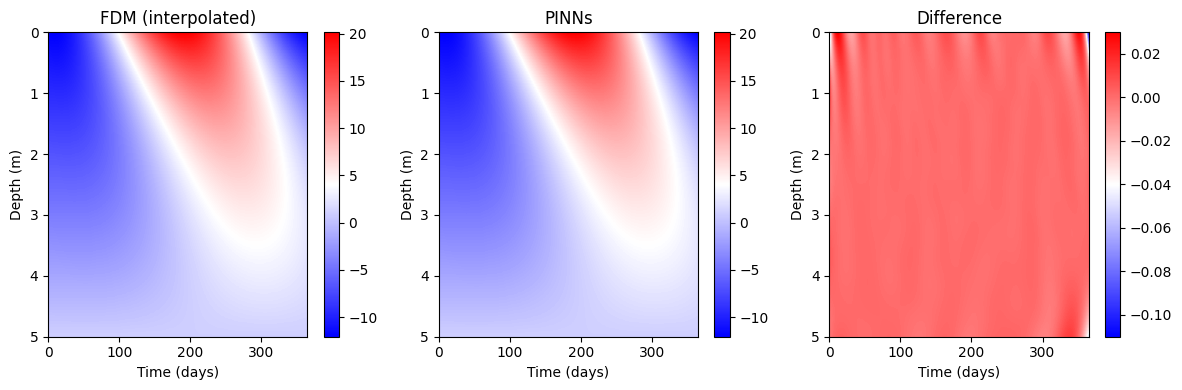

In [9]:
import numpy as np
import matplotlib.pyplot as plt

old_idx = np.linspace(0, 1, T_field_fdm.shape[1])
new_idx = np.linspace(0, 1, T_field_pinn.shape[1])

T_fdm_interp = np.zeros_like(T_field_pinn)
for i in range(T_field_fdm.shape[0]):
    T_fdm_interp[i, :] = np.interp(new_idx, old_idx, T_field_fdm[i, :])

error = T_field_pinn - T_fdm_interp

print("MAE  =", np.mean(np.abs(error)))
print("RMSE =", np.sqrt(np.mean(error**2)))

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(T_fdm_interp, aspect='auto', origin='upper', cmap='bwr',
           extent=[0, 365, 5, 0])
plt.title("FDM (interpolated)")
plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(T_field_pinn, aspect='auto', origin='upper', cmap='bwr',
           extent=[0, 365, 5, 0])
plt.title("PINNs")
plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(error, aspect='auto', origin='upper', cmap='bwr',
           extent=[0, 365, 5, 0])
plt.title("Difference")
plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.colorbar()

plt.tight_layout()
plt.show()

In [13]:
import numpy as np

old_idx = np.linspace(0, 1, T_field_fdm.shape[1])
new_idx = np.linspace(0, 1, T_field_pinn.shape[1])

T_fdm_interp = np.zeros_like(T_field_pinn)
for i in range(T_field_fdm.shape[0]):
    T_fdm_interp[i, :] = np.interp(new_idx, old_idx, T_field_fdm[i, :])

error = T_field_pinn - T_fdm_interp

np.savez(
    "pinn_fdm_results.npz",
    T_field_pinn=T_field_pinn,
    T_fdm_interp=T_fdm_interp,
    error=error
)

print("Saved: pinn_fdm_results.npz")
print("MAE  =", np.mean(np.abs(error)))
print("RMSE =", np.sqrt(np.mean(error**2)))

Saved: pinn_fdm_results.npz
MAE  = 0.0014388255
RMSE = 0.0033123104


In [14]:
import numpy as np
from scipy.io import savemat

data = np.load("pinn_fdm_results.npz")

savemat("pinn_fdm_results.mat", {
    "T_field_pinn": data["T_field_pinn"],
    "T_fdm_interp": data["T_fdm_interp"],
    "error": data["error"]
})